In [ ]:
pip install imbalanced-learn

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import SMOTE

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score, recall_score, f1_score
from sklearn.ensemble import RandomForestClassifier


In [234]:
df1 = pd.read_csv("/content/fake.csv")
df1["news_status"] = "fake"
print(df1)

                                                   title  \
0       Donald Trump Sends Out Embarrassing New Year’...   
1       Drunk Bragging Trump Staffer Started Russian ...   
2       Sheriff David Clarke Becomes An Internet Joke...   
3       Trump Is So Obsessed He Even Has Obama’s Name...   
4       Pope Francis Just Called Out Donald Trump Dur...   
...                                                  ...   
23476  McPain: John McCain Furious That Iran Treated ...   
23477  JUSTICE? Yahoo Settles E-mail Privacy Class-ac...   
23478  Sunnistan: US and Allied ‘Safe Zone’ Plan to T...   
23479  How to Blow $700 Million: Al Jazeera America F...   
23480  10 U.S. Navy Sailors Held by Iranian Military ...   

                                                    text      subject  \
0      Donald Trump just couldn t wish all Americans ...         News   
1      House Intelligence Committee Chairman Devin Nu...         News   
2      On Friday, it was revealed that former Milwauk...    

In [235]:
df2 = pd.read_csv("/content/true.csv")
df2["news_status"] = "True"
print(df2)

                                                   title  \
0      As U.S. budget fight looms, Republicans flip t...   
1      U.S. military to accept transgender recruits o...   
2      Senior U.S. Republican senator: 'Let Mr. Muell...   
3      FBI Russia probe helped by Australian diplomat...   
4      Trump wants Postal Service to charge 'much mor...   
...                                                  ...   
21412  'Fully committed' NATO backs new U.S. approach...   
21413  LexisNexis withdrew two products from Chinese ...   
21414  Minsk cultural hub becomes haven from authorities   
21415  Vatican upbeat on possibility of Pope Francis ...   
21416  Indonesia to buy $1.14 billion worth of Russia...   

                                                    text       subject  \
0      WASHINGTON (Reuters) - The head of a conservat...  politicsNews   
1      WASHINGTON (Reuters) - Transgender people will...  politicsNews   
2      WASHINGTON (Reuters) - The special counsel inv... 

In [236]:
df1.update(df2)
print(df1)

                                                   title  \
0      As U.S. budget fight looms, Republicans flip t...   
1      U.S. military to accept transgender recruits o...   
2      Senior U.S. Republican senator: 'Let Mr. Muell...   
3      FBI Russia probe helped by Australian diplomat...   
4      Trump wants Postal Service to charge 'much mor...   
...                                                  ...   
23476  McPain: John McCain Furious That Iran Treated ...   
23477  JUSTICE? Yahoo Settles E-mail Privacy Class-ac...   
23478  Sunnistan: US and Allied ‘Safe Zone’ Plan to T...   
23479  How to Blow $700 Million: Al Jazeera America F...   
23480  10 U.S. Navy Sailors Held by Iranian Military ...   

                                                    text       subject  \
0      WASHINGTON (Reuters) - The head of a conservat...  politicsNews   
1      WASHINGTON (Reuters) - Transgender people will...  politicsNews   
2      WASHINGTON (Reuters) - The special counsel inv... 

In [237]:
for col_name in df1.columns:
  print(f"{col_name} : {df1[col_name].dtype}")

title : object
text : object
subject : object
date : object
news_status : object


In [238]:
le = LabelEncoder()
scaler = StandardScaler()

for col in df1:
  if df1[col].dtype == "object" and col != "news_status":
    df1[col] = le.fit_transform(df1[col].astype(str))


df1['date'] = pd.to_datetime(df1['date'])

df1["news_status"] = df1.apply(lambda row: 1 if row["news_status"] == "True" else 0, axis=1)
print(df1)

df1.drop('date', axis = 1, inplace=True)


y = df1['news_status']
x = df1.drop(['news_status'], axis=1)

for col in df1:
  if df1[col].isnull().sum() > 0 and df1[col].dtype != "object":
    df1.fillna(df1[col].mean(), inplace=True)
  else:
    imputer = SimpleImputer(strategy="most_frequent")
    df1[col] = imputer.fit_transform(df1[[col]]).ravel()




       title   text  subject                          date  news_status
0        786  19762        3 1970-01-01 00:00:00.000000323            1
1      20095  20020        3 1970-01-01 00:00:00.000000313            1
2      14421  19877        3 1970-01-01 00:00:00.000000323            1
3       4882  20025        3 1970-01-01 00:00:00.000000320            1
4      17994  13599        3 1970-01-01 00:00:00.000000313            1
...      ...    ...      ...                           ...          ...
23476   9651   1957        0 1970-01-01 00:00:00.000000453            0
23477   8253   2065        0 1970-01-01 00:00:00.000000453            0
23478  15121  12930        0 1970-01-01 00:00:00.000000449            0
23479   7151   1947        0 1970-01-01 00:00:00.000000445            0
23480    187   1956        0 1970-01-01 00:00:00.000000439            0

[23481 rows x 5 columns]


In [239]:
df1['news_status'].dtype

dtype('int64')

In [240]:
df1['news_status']

,news_status
0,1
1,1
2,1
3,1
4,1
...,...
23476,0
23477,0
23478,0
23479,0


In [241]:
y.value_counts()

,count
news_status,
1,21417
0,2064


In [247]:
smote = SMOTE(random_state=42)
x_resampled, y_resampled = smote.fit_resample(x, y)

print("Original y_train value counts:")
print(y.value_counts())
print("\nResampled y_train value counts (after SMOTE):")
print(y_resampled.value_counts())

Original y_train value counts:
news_status
1    21417
0     2064
Name: count, dtype: int64

Resampled y_train value counts (after SMOTE):
news_status
1    21417
0    21417
Name: count, dtype: int64


In [249]:
x_train, x_test, y_train, y_test = train_test_split(x_resampled, y_resampled, test_size=0.2, random_state=42)

In [246]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(34267, 3)
(8567, 3)
(34267,)
(8567,)


In [250]:
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score)

xgb_model = XGBClassifier(
   n_estimators=300,
    learning_rate=0.1,
    max_depth=5,

    random_state=42,
    n_jobs=-1,

    colsample_bytree=0.7,
    subsample=0.8,

    objective='binary:logistic'
    # tree_method='auto'
   )

xgb_model.fit(x_train, y_train)
y_pred = xgb_model.predict(x_test)

accuracy_scores = accuracy_score(y_test, y_pred)
precision_scores = precision_score(y_test, y_pred)
recall_scores = recall_score(y_test, y_pred)
f1_scores = f1_score(y_test, y_pred) # caluculate metrics considering class imbalance

print(f"""
Accuracy Score : {accuracy_scores}
Precision Score : {precision_scores}
Recall Score : {recall_scores}
F1 Score : {f1_scores} """)

# r2_score = r2_score(y_test, y_pred)
# mae = mean_absolute_error(y_test, y_pred)
# mse = mean_squared_error(y_test, y_pred)

# print(f"R2 Score: {r2_score}")
# print(f"Mean Absolute Error: {mae}")
# print(f"Mean Squared Error: {mse}")


Accuracy Score : 1.0
Precision Score : 1.0
Recall Score : 1.0
F1 Score : 1.0 


In [245]:
y_train.value_counts()

,count
news_status,
0,17138
1,17129


In [251]:
y_test.value_counts()

,count
news_status,
1,4288
0,4279


              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4279
           1       1.00      1.00      1.00      4288

    accuracy                           1.00      8567
   macro avg       1.00      1.00      1.00      8567
weighted avg       1.00      1.00      1.00      8567



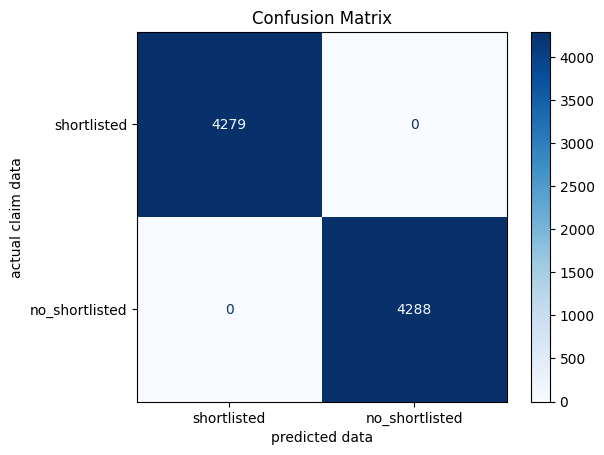

In [252]:
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['shortlisted', 'no_shortlisted']) # Assuming binary classification for 'liked'
disp.plot(cmap=plt.cm.Blues)

plt.xlabel('predicted data')
plt.ylabel('actual claim data')
plt.title('Confusion Matrix')
plt.show()

In [169]:
import joblib
if joblib.dump(xgb_model, 'fake news detection.pkl'):
  print("model saved")

model saved
